# Laplace and Poisson Relaxation Solvers

Capacitor potentials and electric fields using Jacobi and Gauss–Seidel relaxation, plus localized charge sources.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


width of plates (a) in units of L: 0.5
plate separation (b) in units of L: 0.2
grid cell size (dx = dy = dL) in units of L: 0.01
acceptable local error as fraction of V0 (e.g. 1e-5): 0.00001

=== Converged ===
N = 101 grid points per side, dL = 0.01
iterations = 2030, final deltaV_avg = 9.995e-06


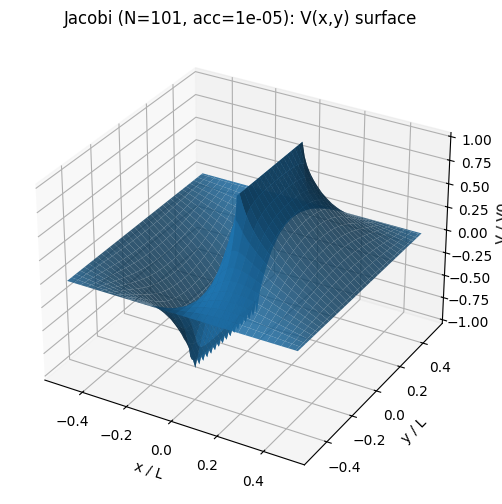

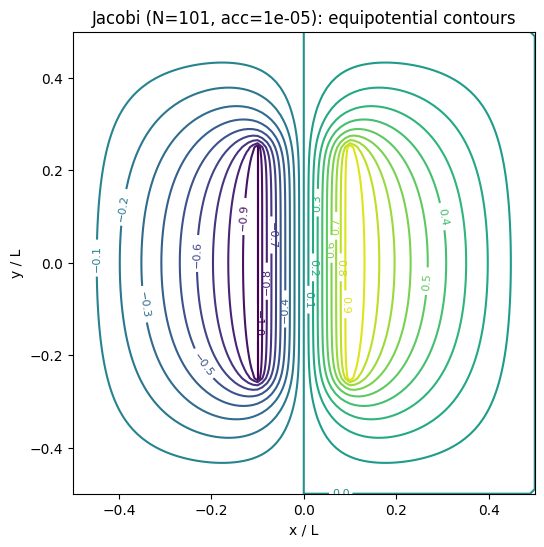

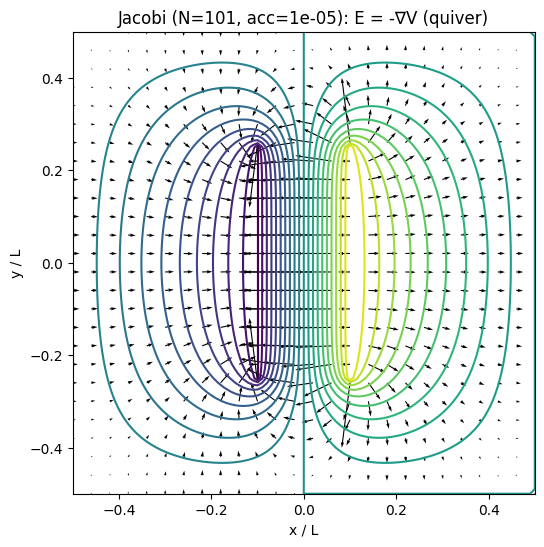

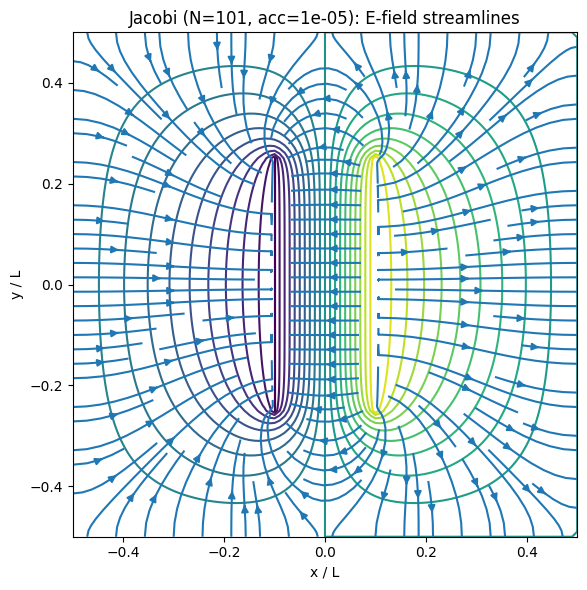


Run convergence sweeps? (y/n): y

--- Sweep 1: iterations vs mesh size (fixed acc) ---
dL_in	N	iters(meas)	iters(theory)
0.05000	21	152		930
0.04000	27	225		1574
0.03000	35	390		2694
0.02500	41	490		3729
0.02000	51	703		5829

--- Sweep 2: iterations vs accuracy (fixed mesh) ---
acc		iters(meas)	iters(theory)
1.0e-02	1		9331
3.0e-03	4		11770
1.0e-03	35		13996
3.0e-04	168		16436
1.0e-04	704		18661
3.0e-05	1397		21101
1.0e-05	2030		23327

Notes for write-up:
• Expect iters ~ O(N^2) for fixed acc (since 1-ρ ~ π^2/(2N^2)).
• Expect iters ~ O(log(1/acc)) for fixed N (geometric convergence).


In [ ]:
# Lab 7 - Task 1

import numpy as np;
import matplotlib.pyplot as plt;
from math import floor, pi, log;

# Geometry + Grid setup
def setup_grid(a, b, dL_in):
    # grid rounding like starter code
    M = floor(0.5 / dL_in + 0.5);
    dL = 1.0 / (2 * M);
    N = 2 * M + 1;
    aM = floor(a * M + 0.5);
    bM = floor(b * M + 0.5);

    # coordinates: physical x,y in [-0.5, +0.5]
    xvals = np.array([-0.5 + i * dL for i in range(N)]);
    yvals = np.array([-0.5 + i * dL for i in range(N)]);
    X, Y = np.meshgrid(xvals, yvals, indexing = "xy");  # X[j], Y[i] style & arrays shape (N,N)

    # potential array V[i,j] corresponds to (x = X[i,j], y = Y[i,j])
    V = np.zeros((N, N), dtype = float);

    params = dict(M = M, N = N, dL = dL, aM = aM, bM = bM, a = a, b = b);
    apply_boundary_conditions(V, params);
    return V, X, Y, params;

# No infinite loop when theres nothing to calculate
def apply_boundary_conditions(V, params):
    M, aM, bM = params["M"], params["aM"], params["bM"];
    xL = M - bM;   # left plate column
    xR = M + bM;  # right plate column
    # y runs over rows
    for y in range(M - aM, M + aM + 1):
        V[y, xL] = -1.0;
        V[y, xR] = +1.0;


# Jacobi update + solver
def update_jacobi(V, params):
    # Indexing: V[row, col] = V[y_index, x_index]
    ny, nx = V.shape;
    Vnew = np.zeros_like(V);

    # Apply fixed Dirichlet BCs (plates + boundaries)
    apply_boundary_conditions(Vnew, params);

    M, aM, bM = params["M"], params["aM"], params["bM"];
    xL = M - bM;
    xR = M + bM;
    y_min = M - aM;
    y_max = M + aM;

    delta = 0.0;
    for i in range(1, ny - 1):        # i = row (y)
        for j in range(1, nx - 1):    # j = col (x)

            # Skip plate points so they remain fixed at ±1
            if (j == xL or j == xR) and (y_min <= i <= y_max):
                continue;

            # Jacobi neighbor average (Laplace stencil)
            Vnew[i, j] = 0.25 * (V[i-1, j] + V[i+1, j] + V[i, j-1] + V[i, j+1]);
            delta += abs(Vnew[i, j] - V[i, j]);

    delta /= (nx * ny);
    return Vnew, delta;

# Iterate until deltaV_avg < acc (acc is fraction of V0 since we use +/-1 plates)
def solve_jacobi(V0, params, acc = 1e-5, max_iter = 2_000_000, record_history = False):
    V = V0.copy();
    history = [];
    delta = 1e99;
    it = 0;
    while delta > acc and it < max_iter:
        V, delta = update_jacobi(V, params);
        it += 1;
        if record_history and (it % 10 == 0 or it <= 50):
            history.append((it, delta));
    return V, it, delta, history;


# E Field from potential
def compute_E(V, params):
    dL = params["dL"];
    Ex = np.zeros_like(V);
    Ey = np.zeros_like(V);
    # central differences interior
    Ex[:, 1:-1] = -(V[:, 2:] - V[:, :-2]) / (2 * dL);   # dV/dx across columns
    Ey[1:-1, :] = -(V[2:, :] - V[:-2, :]) / (2 * dL);   # dV/dy across rows
    # one-sided at boundaries (box edges)
    Ex[:, 0]  = -(V[:, 1] - V[:, 0]) / dL;
    Ex[:, -1] = -(V[:, -1] - V[:, -2]) / dL;
    Ey[0, :]  = -(V[1, :] - V[0, :]) / dL;
    Ey[-1, :] = -(V[-1, :] - V[-2, :]) / dL;

    return Ex, Ey;


# Plotting
def plot_results(V, X, Y, Ex, Ey, params, title_prefix = "Jacobi solution"):
    N = params["N"];

    # Potential surface
    fig1 = plt.figure(figsize = (8, 6));
    ax1 = fig1.add_subplot(111, projection = "3d");
    ax1.plot_surface(X, Y, V, linewidth = 0, antialiased = True, alpha = 0.85);
    ax1.set_title(f"{title_prefix}: V(x,y) surface");
    ax1.set_xlabel("x / L");
    ax1.set_ylabel("y / L");
    ax1.set_zlabel("V / V0");

    # Equipotential contours
    fig2 = plt.figure(figsize = (7, 6));
    ax2 = fig2.add_subplot(111);
    cs = ax2.contour(X, Y, V, levels = 20);
    ax2.clabel(cs, inline = True, fontsize = 8);
    ax2.set_title(f"{title_prefix}: equipotential contours");
    ax2.set_xlabel("x / L");
    ax2.set_ylabel("y / L");
    ax2.set_aspect("equal", adjustable = "box");

    # E-field vectors (downsample so arrows are readable)
    step = max(1, N // 25);
    fig3 = plt.figure(figsize = (7, 6));
    ax3 = fig3.add_subplot(111);
    ax3.contour(X, Y, V, levels = 20);
    ax3.quiver(X[::step, ::step], Y[::step, ::step], Ex[::step, ::step], Ey[::step, ::step]);
    ax3.set_title(f"{title_prefix}: E = -∇V (quiver)");
    ax3.set_xlabel("x / L");
    ax3.set_ylabel("y / L");
    ax3.set_aspect("equal", adjustable = "box");

    # Streamlines
    fig4 = plt.figure(figsize = (7, 6));
    ax4 = fig4.add_subplot(111);
    ax4.contour(X, Y, V, levels = 20);
    ax4.streamplot(X, Y, Ex, Ey, density = 1.2);
    ax4.set_title(f"{title_prefix}: E-field streamlines");
    ax4.set_xlabel("x / L");
    ax4.set_ylabel("y / L");
    ax4.set_aspect("equal", adjustable = "box");

    plt.tight_layout();
    plt.show();


# Convergence theory for Jacobi
def jacobi_theory_iters(N, acc, C = 1.0):
    n = max(3, N - 1);
    rho = np.cos(np.pi / n);
    return int(np.ceil(np.log(C / acc) / (-np.log(rho))));


# Main
if __name__ == "__main__":
    # User inputs
    a = float(input("width of plates (a) in units of L: "));
    b = float(input("plate separation (b) in units of L: "));
    dL_in = float(input("grid cell size (dx = dy = dL) in units of L: "));
    acc = float(input("acceptable local error as fraction of V0 (e.g. 1e-5): "));

    # Solve once and plot
    V0, X, Y, params = setup_grid(a, b, dL_in);
    V, iters, delta_last, hist = solve_jacobi(V0, params, acc = acc, record_history = True);

    print("\n=== Converged ===");
    print(f"N = {params['N']} grid points per side, dL = {params['dL']:.6g}");
    print(f"iterations = {iters}, final deltaV_avg = {delta_last:.3e}");

    Ex, Ey = compute_E(V, params);
    plot_results(V, X, Y, Ex, Ey, params, title_prefix = f"Jacobi (N = {params['N']}, acc = {acc:g})");

    # Convergence checks
    do_sweep = input("\nRun convergence sweeps? (y/n): ").strip().lower() == "y";
    if do_sweep:
        # iterations vs mesh size at fixed accuracy
        print("\n--- Sweep 1: iterations vs mesh size (fixed acc) ---");
        dLs = [0.05, 0.04, 0.03, 0.025, 0.02];
        print("dL_in\tN\titers(meas)\titers(theory)");
        for dLtest in dLs:
            Vt, Xt, Yt, pt = setup_grid(a, b, dLtest);
            _, it, _, _ = solve_jacobi(Vt, pt, acc = acc, record_history = False, max_iter = 2_000_000);
            it_th = jacobi_theory_iters(pt["N"], acc);
            print(f"{dLtest:.5f}\t{pt['N']}\t{it}\t\t{it_th}");

        # iterations vs desired accuracy at fixed mesh
        print("\n--- Sweep 2: iterations vs accuracy (fixed mesh) ---");
        accs = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5];
        # Use the already-built mesh params from the first run:
        Vt, Xt, Yt, pt = setup_grid(a, b, dL_in);
        print("acc\t\titers(meas)\titers(theory)");
        for acctest in accs:
            _, it, _, _ = solve_jacobi(Vt, pt, acc = acctest, record_history = False, max_iter = 2_000_000);
            it_th = jacobi_theory_iters(pt["N"], acctest);
            print(f"{acctest:.1e}\t{it}\t\t{it_th}");


# EOF



width of plates (a) in units of L: 0.5
plate separation (b) in units of L: 0.2
grid cell size (dx = dy = dL) in units of L: 0.01
acceptable local error as fraction of V0 (e.g. 1e-5): 0.00001

=== Gauss–Seidel Converged ===
N = 101 grid points per side, dL = 0.01
iterations = 1216, final deltaV_avg = 9.982e-06


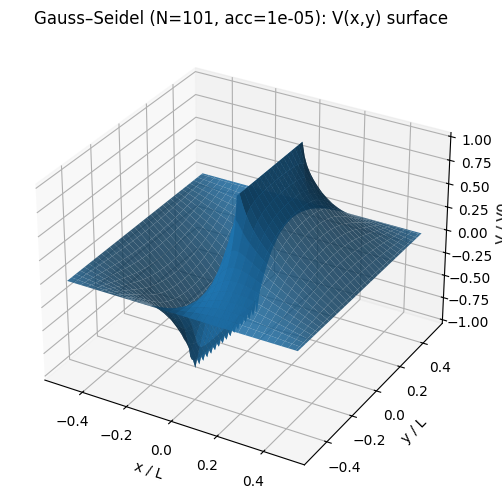

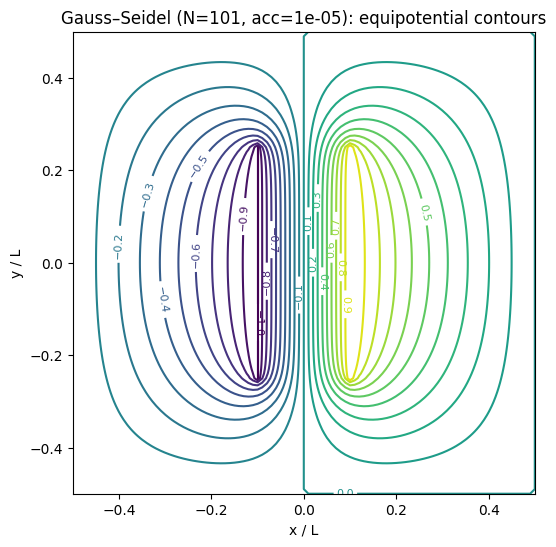

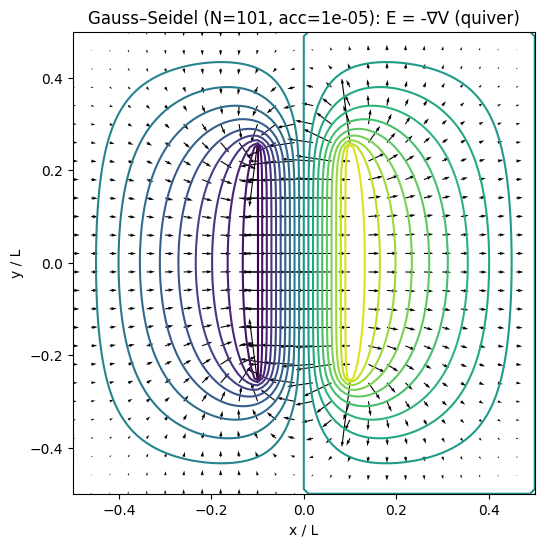

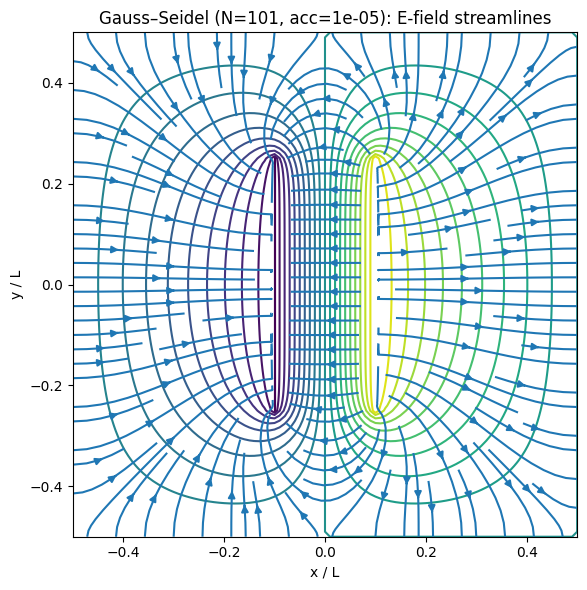


Run convergence sweeps? (y/n): y

--- Sweep 1: iterations vs mesh size (fixed acc) ---
dL_in	N	GS	Jacobi	(Jacobi/GS)	JacobiTheory
0.05000	21	85	152	1.79		930
0.04000	27	126	225	1.79		1574
0.03000	35	220	390	1.77		2694
0.02500	41	278	490	1.76		3729
0.02000	51	402	703	1.75		5829

--- Sweep 2: iterations vs accuracy (fixed mesh) ---
acc		GS	Jacobi	(Jacobi/GS)	JacobiTheory
1.0e-02	1	1	1.00		9331
3.0e-03	9	4	0.44		11770
1.0e-03	45	35	0.78		13996
3.0e-04	239	168	0.70		16436
1.0e-04	552	704	1.28		18661
3.0e-05	899	1397	1.55		21101
1.0e-05	1216	2030	1.67		23327

Notes for write-up:
• GS uses in-place updates (new values reused immediately), reducing the effective spectral radius.
• Expect GS to converge noticeably faster than Jacobi (often ~1.5–2.5× fewer sweeps).
• Both still show worse convergence for larger N and tighter accuracy; Jacobi scaling ~ N^2 log(1/acc).


In [ ]:
# Lab 7 - Task 2

import numpy as np;
import matplotlib.pyplot as plt;
from math import floor, pi;


# Geometry + Grid setup
def setup_grid(a, b, dL_in):
    M = floor(0.5 / dL_in + 0.5);
    dL = 1.0 / (2 * M);
    N = 2 * M + 1;
    aM = floor(a * M + 0.5);
    bM = floor(b * M + 0.5);

    xvals = np.array([-0.5 + i * dL for i in range(N)]);
    yvals = np.array([-0.5 + i * dL for i in range(N)]);
    X, Y = np.meshgrid(xvals, yvals, indexing = "xy");
    V = np.zeros((N, N), dtype = float);

    params = dict(M = M, N = N, dL = dL, aM = aM, bM = bM, a = a, b = b);
    apply_boundary_conditions(V, params);
    return V, X, Y, params;

# Preventing the infinite loop
def apply_boundary_conditions(V, params):
    M, aM, bM = params["M"], params["aM"], params["bM"];
    xL = M - bM;
    xR = M + bM;
    for y in range(M - aM, M + aM + 1):
        V[y, xL] = -1.0;
        V[y, xR] = +1.0;


# Jacobi (kept for comparison)
def update_jacobi(V, params):
    ny, nx = V.shape;
    Vnew = np.zeros_like(V);
    apply_boundary_conditions(Vnew, params);

    M, aM, bM = params["M"], params["aM"], params["bM"];
    xL = M - bM;
    xR = M + bM;
    y_min = M - aM;
    y_max = M + aM;

    delta = 0.0;
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            if (j == xL or j == xR) and (y_min <= i <= y_max):
                continue;
            Vnew[i, j] = 0.25 * (V[i-1, j] + V[i+1, j] + V[i, j-1] + V[i, j+1]);
            delta += abs(Vnew[i, j] - V[i, j]);

    delta /= (nx * ny);
    return Vnew, delta;


def solve_jacobi(V0, params, acc = 1e-5, max_iter = 2_000_000):
    V = V0.copy();
    delta = 1e99;
    it = 0;
    while delta > acc and it < max_iter:
        V, delta = update_jacobi(V, params);
        it += 1;
    return V, it, delta


# Gauss–Seidel update + solver
def update_gauss_seidel(V, params):
    ny, nx = V.shape;
    M, aM, bM = params["M"], params["aM"], params["bM"];
    xL = M - bM;
    xR = M + bM;
    y_min = M - aM;
    y_max = M + aM;

    # Enforce BCs before sweep, especially plates
    apply_boundary_conditions(V, params);

    delta = 0.0;
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            # Skip plate points so they remain fixed
            if (j == xL or j == xR) and (y_min <= i <= y_max):
                continue;

            old = V[i, j];
            V[i, j] = 0.25 * (V[i-1, j] + V[i+1, j] + V[i, j-1] + V[i, j+1]);
            delta += abs(V[i, j] - old);

    # Re-enforce BCs just to be sure mate
    apply_boundary_conditions(V, params);

    delta /= (nx * ny);
    return delta;


def solve_gauss_seidel(V0, params, acc = 1e-5, max_iter = 2_000_000):
    V = V0.copy();
    delta = 1e99;
    it = 0;
    while delta > acc and it < max_iter:
        delta = update_gauss_seidel(V, params);
        it += 1;
    return V, it, delta;


# Field from potential
def compute_E(V, params):
    dL = params["dL"];
    Ex = np.zeros_like(V);
    Ey = np.zeros_like(V);

    Ex[:, 1:-1] = -(V[:, 2:] - V[:, :-2]) / (2 * dL);
    Ey[1:-1, :] = -(V[2:, :] - V[:-2, :]) / (2 * dL);

    Ex[:, 0]  = -(V[:, 1] - V[:, 0]) / dL;
    Ex[:, -1] = -(V[:, -1] - V[:, -2]) / dL;
    Ey[0, :]  = -(V[1, :] - V[0, :]) / dL;
    Ey[-1, :] = -(V[-1, :] - V[-2, :]) / dL;

    return Ex, Ey;


# Plotting
def plot_results(V, X, Y, Ex, Ey, params, title_prefix = "GS solution"):
    N = params["N"];
    fig1 = plt.figure(figsize = (8, 6));
    ax1 = fig1.add_subplot(111, projection = "3d");
    ax1.plot_surface(X, Y, V, linewidth = 0, antialiased = True, alpha = 0.85);
    ax1.set_title(f"{title_prefix}: V(x,y) surface");
    ax1.set_xlabel("x / L");
    ax1.set_ylabel("y / L");
    ax1.set_zlabel("V / V0");

    fig2 = plt.figure(figsize = (7, 6));
    ax2 = fig2.add_subplot(111);
    cs = ax2.contour(X, Y, V, levels = 20);
    ax2.clabel(cs, inline = True, fontsize = 8);
    ax2.set_title(f"{title_prefix}: equipotential contours");
    ax2.set_xlabel("x / L");
    ax2.set_ylabel("y / L");
    ax2.set_aspect("equal", adjustable = "box");

    step = max(1, N // 25);
    fig3 = plt.figure(figsize = (7, 6));
    ax3 = fig3.add_subplot(111);
    ax3.contour(X, Y, V, levels = 20);
    ax3.quiver(X[::step, ::step], Y[::step, ::step], Ex[::step, ::step], Ey[::step, ::step]);
    ax3.set_title(f"{title_prefix}: E = -∇V (quiver)");
    ax3.set_xlabel("x / L");
    ax3.set_ylabel("y / L");
    ax3.set_aspect("equal", adjustable = "box");

    fig4 = plt.figure(figsize = (7, 6));
    ax4 = fig4.add_subplot(111);
    ax4.contour(X, Y, V, levels = 20);
    ax4.streamplot(X, Y, Ex, Ey, density = 1.2);
    ax4.set_title(f"{title_prefix}: E-field streamlines");
    ax4.set_xlabel("x / L");
    ax4.set_ylabel("y / L");
    ax4.set_aspect("equal", adjustable = "box");

    plt.tight_layout();
    plt.show();


# Simple Jacobi convergence theory for reference
def jacobi_theory_iters(N, acc, C = 1.0):
    n = max(3, N - 1);
    rho = np.cos(np.pi / n);
    return int(np.ceil(np.log(C / acc) / (-np.log(rho))));


# Main
if __name__ == "__main__":
    a = float(input("width of plates (a) in units of L: "));
    b = float(input("plate separation (b) in units of L: "));
    dL_in = float(input("grid cell size (dx = dy = dL) in units of L: "));
    acc = float(input("acceptable local error as fraction of V0 (e.g. 1e-5): "));

    # Solve once with Gauss–Seidel and plot
    V0, X, Y, params = setup_grid(a, b, dL_in);
    Vgs, it_gs, delta_gs = solve_gauss_seidel(V0, params, acc = acc);

    print("\n=== Gauss–Seidel Converged ===");
    print(f"N = {params['N']} grid points per side, dL = {params['dL']:.6g}");
    print(f"iterations = {it_gs}, final deltaV_avg = {delta_gs:.3e}");

    Ex, Ey = compute_E(Vgs, params);
    plot_results(Vgs, X, Y, Ex, Ey, params, title_prefix = f"Gauss–Seidel (N = {params['N']}, acc = {acc:g})");

    # Convergence checks + Jacobi comparison
    do_sweep = input("\nRun convergence sweeps? (y/n): ").strip().lower() == "y";
    if do_sweep:
        dLs = [0.05, 0.04, 0.03, 0.025, 0.02];
        accs = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5];

        print("\n--- Sweep 1: iterations vs mesh size (fixed acc) ---");
        print("dL_in\tN\tGS\tJacobi\t(Jacobi/GS)\tJacobiTheory");
        for dLtest in dLs:
            Vt, _, _, pt = setup_grid(a, b, dLtest);

            Vg, itG, _ = solve_gauss_seidel(Vt, pt, acc = acc);
            Vj, itJ, _ = solve_jacobi(Vt, pt, acc = acc);
            ratio = itJ / itG if itG > 0 else np.nan;
            it_th = jacobi_theory_iters(pt["N"], acc);

            print(f"{dLtest:.5f}\t{pt['N']}\t{itG}\t{itJ}\t{ratio:.2f}\t\t{it_th}");

        print("\n--- Sweep 2: iterations vs accuracy (fixed mesh) ---");
        Vt, _, _, pt = setup_grid(a, b, dL_in);
        print("acc\t\tGS\tJacobi\t(Jacobi/GS)\tJacobiTheory");
        for acctest in accs:
            Vg, itG, _ = solve_gauss_seidel(Vt, pt, acc = acctest);
            Vj, itJ, _ = solve_jacobi(Vt, pt, acc = acctest);
            ratio = itJ / itG if itG > 0 else np.nan;
            it_th = jacobi_theory_iters(pt["N"], acctest);

            print(f"{acctest:.1e}\t{itG}\t{itJ}\t{ratio:.2f}\t\t{it_th}");


# EOF



width of plates (a) in units of L: 0.5
plate separation (b) in units of L: 0.2
grid cell size (dx = dy = dL) in units of L: 0.01
acceptable local error as fraction of V0 (e.g. 1e-5): 0.00001

Choose a source location away from plates and boundaries.
source x0 (in units of L, e.g. 0.25): 0.3
source y0 (in units of L, e.g. 0.30): 0.3
source strength (rho/eps0 in arb units, e.g. 50): 5000

=== Poisson (GS) Converged ===
N = 101 grid points per side, dL = 0.01
source placed at grid (row=80, col=80)
iterations = 1227, final deltaV_avg = 9.991e-06


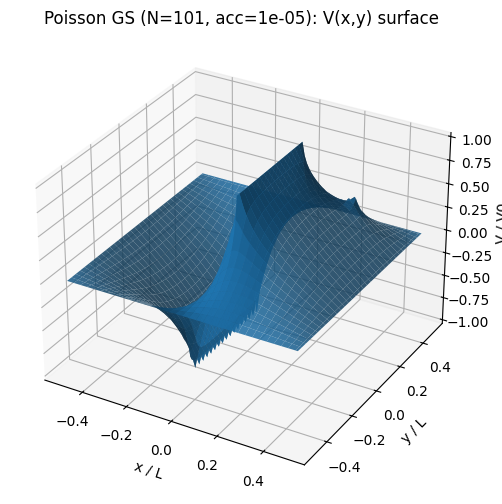

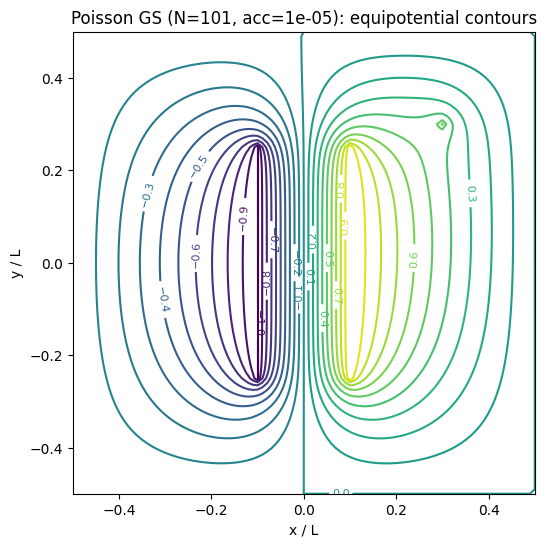

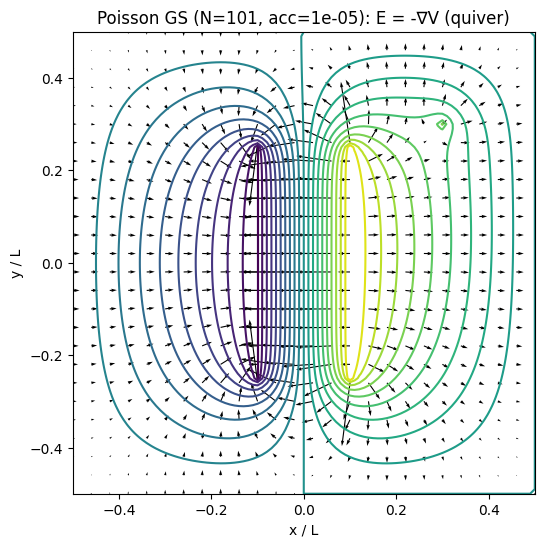

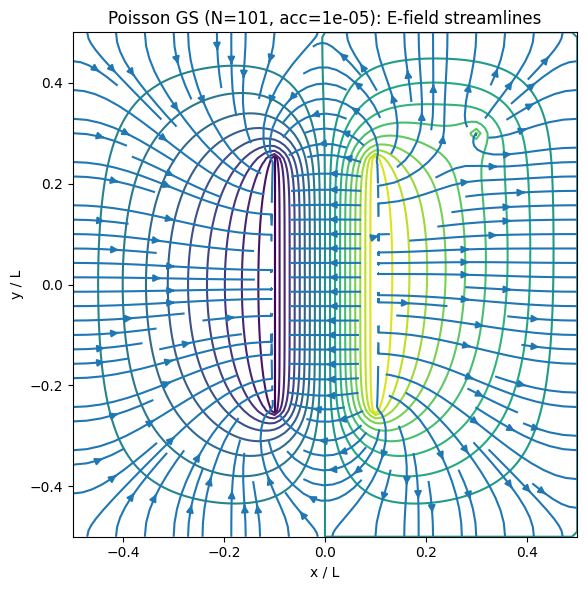

In [ ]:
# Lab 7 - Task 3

import numpy as np;
import matplotlib.pyplot as plt;
from math import floor;

# Geometry + Grid setup
def setup_grid(a, b, dL_in):
    M = floor(0.5 / dL_in + 0.5);
    dL = 1.0 / (2 * M);
    N = 2 * M + 1;
    aM = floor(a * M + 0.5);
    bM = floor(b * M + 0.5);

    xvals = np.array([-0.5 + i * dL for i in range(N)]);
    yvals = np.array([-0.5 + i * dL for i in range(N)]);
    X, Y = np.meshgrid(xvals, yvals, indexing = "xy");

    V = np.zeros((N, N), dtype = float);
    rho = np.zeros_like(V);  # charge density on grid (2D model -> effectively per-unit-length charge)

    params = dict(M = M, N = N, dL = dL, aM = aM, bM = bM, a = a, b = b);
    apply_boundary_conditions(V, params);
    return V, rho, X, Y, params;

# J copy paste it here
def apply_boundary_conditions(V, params):
    M, aM, bM = params["M"], params["aM"], params["bM"];
    xL = M - bM;
    xR = M + bM;
    for y in range(M - aM, M + aM + 1):
        V[y, xL] = -1.0;
        V[y, xR] = +1.0;


# Localized charge -> Poisson source
def add_pointlike_source(rho, params, x0, y0, strength = 1.0):
    # In 2D this corresponds to a line charge (per unit length in z),not a true 3D point charge.
    M, dL, N = params["M"], params["dL"], params["N"];
    # convert physical coords -> nearest grid indices
    j = int(round((x0 + 0.5) / dL));
    i = int(round((y0 + 0.5) / dL));
    # keep it away from boundaries
    i = max(1, min(N - 2, i));
    j = max(1, min(N - 2, j));

    rho[:, :] = 0.0;
    rho[i, j] = strength;
    return (i, j);


# Poisson Gauss–Seidel update + solver
def update_gauss_seidel_poisson(V, rho_over_eps0, params):
    ny, nx = V.shape;
    M, aM, bM = params["M"], params["aM"], params["bM"];
    h = params["dL"];

    xL = M - bM;
    xR = M + bM;
    y_min = M - aM;
    y_max = M + aM;

    apply_boundary_conditions(V, params);

    delta = 0.0;
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            # skip plate points
            if (j == xL or j == xR) and (y_min <= i <= y_max):
                continue;

            old = V[i, j];
            V[i, j] = 0.25 * (V[i-1, j] + V[i+1, j] + V[i, j-1] + V[i, j+1] + (h * h) * rho_over_eps0[i, j]);
            delta += abs(V[i, j] - old);

    apply_boundary_conditions(V, params);
    delta /= (nx * ny);
    return delta;


def solve_gs_poisson(V0, rho_over_eps0, params, acc = 1e-5, max_iter = 2_000_000):
    V = V0.copy();
    delta = 1e99;
    it = 0;
    while delta > acc and it < max_iter:
        delta = update_gauss_seidel_poisson(V, rho_over_eps0, params);
        it += 1;
    return V, it, delta;


# E Field from potential
def compute_E(V, params):
    dL = params["dL"];
    Ex = np.zeros_like(V);
    Ey = np.zeros_like(V);

    Ex[:, 1:-1] = -(V[:, 2:] - V[:, :-2]) / (2 * dL);
    Ey[1:-1, :] = -(V[2:, :] - V[:-2, :]) / (2 * dL);

    Ex[:, 0]  = -(V[:, 1] - V[:, 0]) / dL;
    Ex[:, -1] = -(V[:, -1] - V[:, -2]) / dL;
    Ey[0, :]  = -(V[1, :] - V[0, :]) / dL;
    Ey[-1, :] = -(V[-1, :] - V[-2, :]) / dL;

    return Ex, Ey;


# Plotting
def plot_results(V, X, Y, Ex, Ey, params, title_prefix = "Poisson (GS)"):
    N = params["N"];
    fig1 = plt.figure(figsize = (8, 6));
    ax1 = fig1.add_subplot(111, projection = "3d");
    ax1.plot_surface(X, Y, V, linewidth = 0, antialiased = True, alpha = 0.85);
    ax1.set_title(f"{title_prefix}: V(x,y) surface");
    ax1.set_xlabel("x / L");
    ax1.set_ylabel("y / L");
    ax1.set_zlabel("V / V0");

    fig2 = plt.figure(figsize = (7, 6));
    ax2 = fig2.add_subplot(111);
    cs = ax2.contour(X, Y, V, levels = 20);
    ax2.clabel(cs, inline = True, fontsize = 8);
    ax2.set_title(f"{title_prefix}: equipotential contours");
    ax2.set_xlabel("x / L");
    ax2.set_ylabel("y / L");
    ax2.set_aspect("equal", adjustable = "box");

    step = max(1, N // 25);
    fig3 = plt.figure(figsize = (7, 6));
    ax3 = fig3.add_subplot(111);
    ax3.contour(X, Y, V, levels = 20);
    ax3.quiver(X[::step, ::step], Y[::step, ::step], Ex[::step, ::step], Ey[::step, ::step]);
    ax3.set_title(f"{title_prefix}: E = -∇V (quiver)");
    ax3.set_xlabel("x / L");
    ax3.set_ylabel("y / L");
    ax3.set_aspect("equal", adjustable = "box");

    fig4 = plt.figure(figsize = (7, 6));
    ax4 = fig4.add_subplot(111);
    ax4.contour(X, Y, V, levels = 20);
    ax4.streamplot(X, Y, Ex, Ey, density = 1.2);
    ax4.set_title(f"{title_prefix}: E-field streamlines");
    ax4.set_xlabel("x / L");
    ax4.set_ylabel("y / L");
    ax4.set_aspect("equal", adjustable = "box");

    plt.tight_layout();
    plt.show();


# Main
if __name__ == "__main__":
    a = float(input("width of plates (a) in units of L: "));
    b = float(input("plate separation (b) in units of L: "));
    dL_in = float(input("grid cell size (dx = dy = dL) in units of L: "));
    acc = float(input("acceptable local error as fraction of V0 (e.g. 1e-5): "));

    print("\nChoose a source location away from plates and boundaries.");
    x0 = float(input("source x0 (in units of L, e.g. 0.25): "));
    y0 = float(input("source y0 (in units of L, e.g. 0.30): "));
    strength = float(input("source strength (rho/eps0 in arb units, e.g. 50): "));

    V0, rho, X, Y, params = setup_grid(a, b, dL_in);
    (iy, jx) = add_pointlike_source(rho, params, x0, y0, strength = strength);

    V, iters, delta_last = solve_gs_poisson(V0, rho, params, acc = acc);

    print("\n=== Poisson (GS) Converged ===");
    print(f"N = {params['N']} grid points per side, dL = {params['dL']:.6g}");
    print(f"source placed at grid (row = {iy}, col = {jx})");
    print(f"iterations = {iters}, final deltaV_avg = {delta_last:.3e}");

    Ex, Ey = compute_E(V, params);
    plot_results(V, X, Y, Ex, Ey, params, title_prefix = f"Poisson GS (N = {params['N']}, acc = {acc:g})");


# EOF

